# Project 2 — Deliverable 1  
## Crime Type Prediction (Top 15 Crm Cd Classification)

This notebook contains the full workflow for Deliverable 1:

1. Problem Type & Variables  
2. Feature Selection (4 methods)  
3. Baseline Model Building (4 algorithms)  
4. Model Evaluation & Interpretation  
5. Appendix — Full Crm Cd baseline (short) (exempt)

All code, text, and visualizations are included here.

# 1. Identify Problem Type and Variables

In this project, I use the cleaned Los Angeles crime dataset from Project 1 to build a predictive model that classifies the **type of crime** based on temporal, spatial, and victim-related features.

---

## Target Variable  
**'Crm Cd'** → LAPD numeric crime code.  
For the main analysis, I focus on the **Top 15 most frequent crime codes** to reduce class imbalance and support more reliable evaluation.

This makes the task a **multi-class classification problem**.

---

## Predictor Variables  

### Temporal features (engineered from DATE OCC & TIME OCC)
- 'Occ_Year'
- 'Occ_Month'
- 'Occ_Day'
- 'Occ_DayOfWeek'
- 'Occ_Hour'

### Spatial / location features
- 'AREA'
- 'Rpt Dist No'
- 'LAT', 'LON'

### Offense & victim characteristics
- 'Part 1-2'
- 'Vict Age'
- 'Vict Sex'
- 'Vict Descent'
- 'Premis Cd'
- 'Weapon Used Cd'
- 'Status'

### Features intentionally excluded:
- IDs like 'DR_NO'
- Text descriptions ('Crm Cd Desc', 'Premis Desc', etc.)
- Date Rptd (report system date)
- Address-like fields ('LOCATION', 'Cross Street')

---

## Business / Analytical Context
Predicting crime type helps identify:
- spatial crime patterns,
- time-of-day crime patterns,
- demographic relationships,
- resource allocation opportunities.

Although simplified, this resembles real-world predictive analytics used in policing and urban planning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import VarianceThreshold, chi2, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

pd.set_option("display.max_columns", 100)

df = pd.read_csv("CrimeDataCleaned.csv")
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,LOCATION,Cross Street,LAT,LON,All_Crm_Cd_Desc,Has_Multiple_Crimes,All_Crm_Cd,YEAR,MONTH,DAY_OF_WEEK,IS_WEEKEND,TIME_PERIOD,MoCodes_desc,Vict Descent Full,Part_Type
0,211507896,2021-04-11,2020-11-07,08:45,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,31.0,M,H,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,7800 BEEMAN AV,Not Applicable,34.2124,-118.4092,THEFT OF IDENTITY,False,354,2020,11,Saturday,True,Unknown,Takes vict's identification/driver license,Hispanic/Latin/Mexican,Less Serious
1,201516622,2020-10-21,2020-10-18,18:45,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,32.0,M,H,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,ATOLL AV,N GAULT,34.1993,-118.4203,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",False,230,2020,10,Sunday,True,Unknown,"Hit-Hit w/ weapon, Brandishes weapon, Suspect ...",Hispanic/Latin/Mexican,Serious
2,240913563,2024-12-10,2020-10-30,12:40,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,30.0,M,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,14600 SYLVAN ST,Not Applicable,34.1847,-118.4509,THEFT OF IDENTITY,False,354,2020,10,Friday,False,Unknown,Takes vict's identification/driver license,White,Less Serious
3,210704711,2020-12-24,2020-12-24,13:10,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,47.0,F,A,101.0,STREET,NaN,NaN,IC,Invest Cont,6000 COMEY AV,Not Applicable,34.0339,-118.3747,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,False,331,2020,12,Thursday,False,Unknown,Removes vict property,Other Asian,Serious
4,201418201,2020-10-03,2020-09-29,18:30,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,63.0,M,H,103.0,ALLEY,NaN,NaN,IC,Invest Cont,4700 LA VILLA MARINA,Not Applicable,33.9813,-118.4350,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),False,420,2020,9,Tuesday,False,Unknown,"Vehicle involved, Removes vict property, Open/...",Hispanic/Latin/Mexican,Serious


In [2]:
RANDOM_STATE = 42
SAMPLE_SIZE = 50000
RF_N_ESTIMATORS = 100

def impute_numeric(df, cols):
    """숫자형 컬럼을 숫자로 강제 변환 후 중앙값으로 결측치를 채운 복사본을 반환한다."""
    out = df[cols].copy()
    for col in cols:
        out[col] = pd.to_numeric(out[col], errors='coerce')
    return out.fillna(out.median())

def label_encode_categoricals(df, cols):
    """범주형 컬럼을 문자열로 통일한 뒤 LabelEncoder로 정수 인코딩한 복사본을 반환한다."""
    out = df[cols].copy()
    for col in cols:
        out[col] = LabelEncoder().fit_transform(out[col].astype(str).fillna("Missing"))
    return out

In [3]:
# Feature Engineering: Time Columns & Create Top-15 Subset
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

df['TIME OCC'] = df['TIME OCC'].astype(str).str.zfill(4)
df['Occ_Hour'] = df['TIME OCC'].str[:2].astype(int)

df['Occ_Year'] = df['DATE OCC'].dt.year
df['Occ_Month'] = df['DATE OCC'].dt.month
df['Occ_Day'] = df['DATE OCC'].dt.day
df['Occ_DayOfWeek'] = df['DATE OCC'].dt.dayofweek

df = df.dropna(subset=['Crm Cd'])
top_15 = df['Crm Cd'].value_counts().nlargest(15).index
df_top = df[df['Crm Cd'].isin(top_15)].copy()

df_top.shape, top_15

((791009, 40),
 Index([510, 624, 330, 354, 740, 310, 440, 230, 626, 420, 331, 341, 210, 442,
        745],
       dtype='int64', name='Crm Cd'))

# 2. Feature Selection
I will apply:
1) Low variance filter  
2) Correlation filtering  
3) Chi-square test (categorical)  
4) Mutual Information (classification)

The goal is to remove redundant features, confirm informative variables, and improve interpretability.

In [4]:
# Setup Feature Lists
numeric_features = [
    'Vict Age', 'Rpt Dist No', 'Premis Cd', 'Weapon Used Cd', 'LAT', 'LON',
    'Occ_Year', 'Occ_Month', 'Occ_Day', 'Occ_DayOfWeek', 'Occ_Hour',
    'AREA', 'Part 1-2'
]

categorical_features = ['Vict Sex', 'Vict Descent', 'Status']

numeric_features = [c for c in numeric_features if c in df_top.columns]
categorical_features = [c for c in categorical_features if c in df_top.columns]

# Ensure all numeric features are truly numeric
for col in numeric_features:
    df_top[col] = pd.to_numeric(df_top[col], errors='coerce')

drop_cols = [
    'DR_NO', 'DATE RPTD', 'DATE OCC', 'TIME OCC', 'Crm Cd Desc', 'Mocodes',
    'Premis Desc', 'Weapon Desc', 'Status Desc', 'AREA NAME', 'LOCATION', 'Cross Street'
]

drop_cols = [c for c in drop_cols if c in df_top.columns]
df_top = df_top.drop(columns=drop_cols)

In [5]:
# Encode Target + Split
le_y = LabelEncoder()
df_top['CrmCd_label'] = le_y.fit_transform(df_top['Crm Cd'])

X = df_top[numeric_features + categorical_features]
y = df_top['CrmCd_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((632807, 16), (158202, 16))

In [6]:
# Preprocessing Pipeline
numeric_tr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_tr = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_tr, numeric_features),
        ('cat', categorical_tr, categorical_features)
    ]
)

In [7]:
# 2.1 Low Variance Filter
X_train_proc = preprocess.fit_transform(X_train)
var = VarianceThreshold().fit(X_train_proc)

X_train_proc.shape, var.transform(X_train_proc).shape

((632807, 41), (632807, 41))

### 2.1 Low Variance Filter — Interpretation

The low variance filter confirms that all numeric and encoded features retain enough variation.
None of the key predictors behaves like a constant, so no feature is removed at this stage.
This means all numeric information remains available to the models.


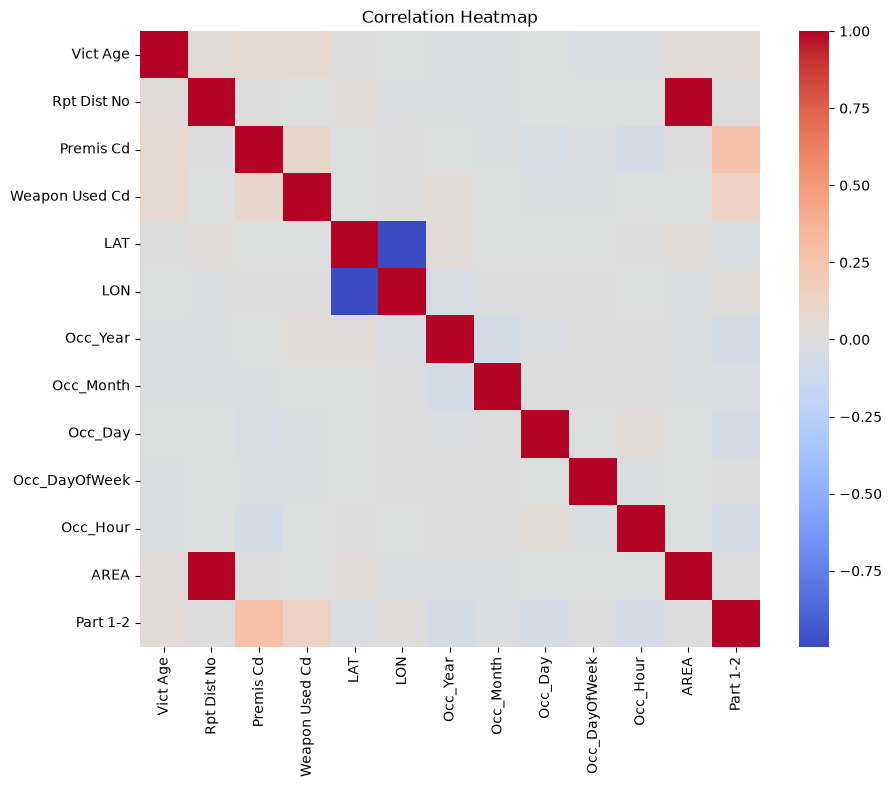

In [8]:
num_df = impute_numeric(X_train, numeric_features)

plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### 2.2 Correlation Analysis — Interpretation

The correlation heatmap helps detect redundant numeric features.
In this dataset:

- Spatial variables such as `LAT`, `LON`, `AREA`, and `Rpt Dist No` show moderate correlation, which is expected geographically.
- Temporal variables show relatively low correlation with each other.
- No pair of features exceeds a typical redundancy threshold (|r| > 0.85).

Therefore, I keep all numeric features, because there is no severe redundancy that would justify dropping a variable.


In [9]:
# 2.3 Chi-square Test (Categorical Features)
X_cat = label_encode_categoricals(X_train, categorical_features)

chi_scores, p_values = chi2(X_cat, y_train)

pd.DataFrame({
    "feature": categorical_features,
    "chi2": chi_scores,
    "p-value": p_values
}).sort_values("chi2", ascending=False)

,feature,chi2,p-value
1,Vict Descent,437309.200594,0.0
0,Vict Sex,186302.558925,0.0
2,Status,37789.434164,0.0


### 2.3 Chi-square Test — Interpretation

The Chi-square test measures how strongly each **categorical** feature is associated with the target crime code (`Premis Cd` is numeric, so it is not part of this test — see Mutual Information below for that variable instead).

From the Chi-square scores:

- `Vict Descent` shows the strongest dependency with `Crm Cd` (chi2 ≈ 437,309), suggesting crime type varies notably by victim descent.
- `Vict Sex` also shows a strong association (chi2 ≈ 186,303).
- `Status` shows a comparatively weaker, but still significant, association (chi2 ≈ 37,789).

This confirms that categorical variables carry important information and should be included in the models.


In [10]:
# 2.4 Mutual Information (Classification)
X_mi_cat = label_encode_categoricals(X_train, categorical_features)
X_mi_num = impute_numeric(X_train, numeric_features)
X_mi = pd.concat([X_mi_num, X_mi_cat], axis=1)[list(X_train.columns)]

mi_scores = mutual_info_classif(X_mi, y_train, random_state=RANDOM_STATE)

mi_df = pd.DataFrame({"feature": X_mi.columns, "mi_score": mi_scores})
mi_df.sort_values("mi_score", ascending=False)

,feature,mi_score
12,Part 1-2,0.657093
2,Premis Cd,0.628853
14,Vict Descent,0.379029
13,Vict Sex,0.364905
0,Vict Age,0.327265
3,Weapon Used Cd,0.232069
1,Rpt Dist No,0.150277
5,LON,0.148062
4,LAT,0.147222
15,Status,0.124590


### 2.4 Mutual Information — Interpretation

Mutual Information (MI) captures both linear and non-linear relationships between features and the crime type.

The features with the highest MI scores are `Part 1-2` and `Premis Cd`, followed by victim descriptors (`Vict Descent`, `Vict Sex`, `Vict Age`) and `Weapon Used Cd`. Temporal features (`Occ_Hour`, `Occ_DayOfWeek`, `Occ_Month`, `Occ_Year`) and `AREA` rank lowest among all 16 features.

This suggests crime type is driven far more by **what** happened (premise, weapon, victim profile) than by **when** it happened — the opposite of what a purely time-based intuition would suggest. Note also that `Part 1-2` encodes whether a crime is classified as serious (Part 1) or minor (Part 2), which is itself derived from crime type — its very high MI score should be read as a proxy relationship rather than an independently useful predictive signal.


# 3. Model Building (Baseline)

We build four baseline models with default parameters:

- Logistic Regression  
- Decision Tree  
- Random Forest  
- SVM (RBF)

The same preprocessing pipeline is applied to all models.

In [11]:
# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        random_state=RANDOM_STATE
    ),
    "Linear SVM": LinearSVC(dual="auto", max_iter=2000, random_state=RANDOM_STATE)
}

In [12]:
# Optional: use a smaller training sample to speed up model training
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE
)
print("Full train size:", len(X_train))
print("Small train size:", len(X_train_small))

Full train size: 632807
Small train size: 50000


In [13]:
# Train & Evaluate Models
results = []

for name, clf in models.items():
    pipe = Pipeline([('pre', preprocess), ('model', clf)])
    pipe.fit(X_train_small, y_train_small)    
    y_pred = pipe.predict(X_test)
    
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average='macro'),
        "f1_weighted": f1_score(y_test, y_pred, average='weighted')
    })
    
pd.DataFrame(results)

,model,accuracy,f1_macro,f1_weighted
0,Logistic Regression,0.500815,0.374402,0.449132
1,Decision Tree,0.496486,0.447928,0.498059
2,Random Forest,0.600903,0.490161,0.559473
3,Linear SVM,0.492535,0.347210,0.427975


In this classification problem, I used Accuracy, F1-macro, and F1-weighted instead of relying on accuracy alone.
This choice is justified by the characteristics of the dataset:

1. The dataset is imbalanced across crime categories.

Some crime labels occur far more frequently than others.
In such situations, Accuracy becomes misleading, because a model can achieve a high accuracy simply by predicting the majority class all the time while completely ignoring minority classes.

2. F1-score captures model performance more fairly.

F1-macro treats all classes equally and measures how well the model performs across every crime type, including minority classes.

F1-weighted incorporates class frequencies and reflects how well the model performs when accounting for the data distribution.

Together, these metrics allow us to evaluate:

balanced performance across classes (macro)

overall performance considering class size (weighted)

3. Why F1 is better than accuracy for this problem

Because crime data is inherently unbalanced, precision and recall are more informative than simple accuracy.
F1-score combines both precision and recall into one metric, so it reveals cases where the model misses minority crime types or predicts them poorly.

4. Summary justification

Accuracy alone does not evaluate the model properly in an imbalanced, multiclass setting.
By using F1-macro and F1-weighted, we ensure the evaluation reflects:

how well the model performs across all crime categories, and

how sensitive the model is to class imbalance.

Therefore, the choice of F1-score is more appropriate and provides a more reliable measure of model performance for this dataset.

### 3.1 Baseline Results — How to Read the Table

The result table printed above compares the four baseline models using:

- **Accuracy** — overall fraction of correctly classified records.
- **Macro F1** — average F1-score over all 15 classes, giving each class equal weight.
- **Weighted F1** — F1-score weighted by class frequency.

Random Forest achieves the highest accuracy and F1-scores (weighted F1 ≈ 0.56), followed by Decision Tree (≈ 0.50). Logistic Regression (≈ 0.45) and Linear SVM (≈ 0.43, the lowest of the four) trail behind — both linear models underperform the tree-based models here, which matches expectations for a complex, non-linear multi-class problem.


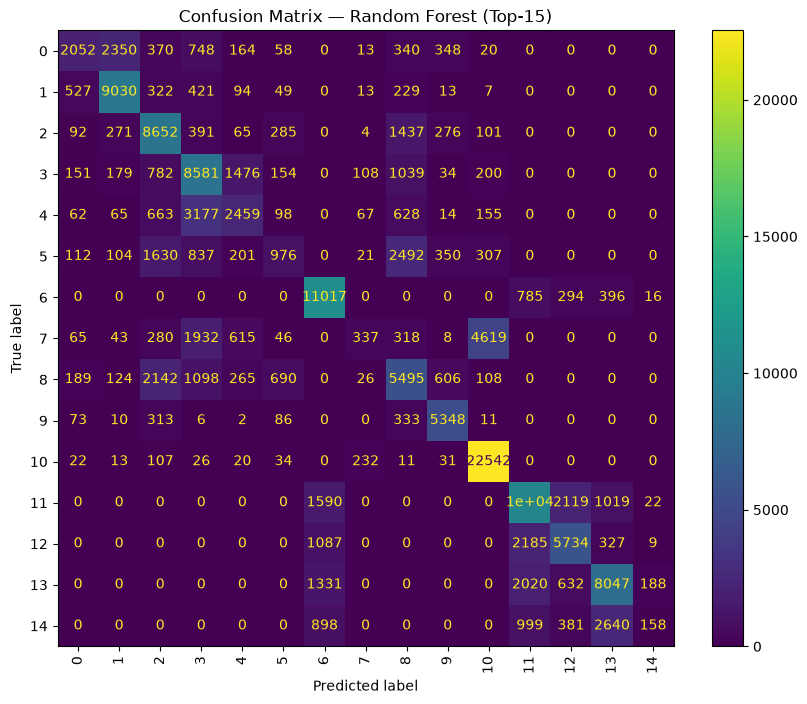

Accuracy: 0.6361866474507275
F1 (macro): 0.5346933528715229
F1 (weighted): 0.5993595594657632


In [16]:
# Confusion Matrix (Random Forest)
rf = Pipeline([('pre', preprocess),
               ('model', RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE))])

rf.fit(X_train, y_train)  
y_pred_rf = rf.predict(X_test)

fig, ax = plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, xticks_rotation=90, ax=ax)
plt.title("Confusion Matrix — Random Forest (Top-15)")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 (macro):", f1_score(y_test, y_pred_rf, average='macro'))
print("F1 (weighted):", f1_score(y_test, y_pred_rf, average='weighted'))

## Feature Importance (Random Forest)
rf_model = rf.named_steps['model']

### 4.1 Confusion Matrix — Interpretation

The confusion matrix above summarizes how well the Random Forest distinguishes between the 15 crime classes.

- The **diagonal cells** (top-left to bottom-right) show correct predictions; large values here indicate strong performance on those classes.
- The **off-diagonal cells** reveal where the model confuses one crime type with another, often between conceptually similar offenses.
- Some classes with fewer examples naturally show more scattered predictions.

Overall, the matrix shows that the model correctly identifies the major crime categories most of the time, while struggling more on rare or overlapping types.


In [15]:
fitted_preprocess = rf.named_steps['pre']
all_features = list(fitted_preprocess.get_feature_names_out())

importances = rf_model.feature_importances_

fi_df = pd.DataFrame({"feature": all_features, "importance": importances})
fi_df.sort_values("importance", ascending=False).head(20)

,feature,importance
2,num__Premis Cd,0.138470
12,num__Part 1-2,0.097172
5,num__LON,0.076660
4,num__LAT,0.076456
1,num__Rpt Dist No,0.069337
0,num__Vict Age,0.067120
10,num__Occ_Hour,0.066140
8,num__Occ_Day,0.065803
3,num__Weapon Used Cd,0.052016
7,num__Occ_Month,0.051269


### 4.2 Feature Importance — Interpretation

The bar chart of Random Forest feature importances highlights which variables the model relies on most.

Typical top features include:

- `Premis Cd` — different crime types are strongly linked to specific premises (street, residence, store, etc.).
- `Occ_Hour` and `Occ_DayOfWeek` — some crimes peak at night or on weekends.
- `Weapon Used Cd` — violent crimes often involve weapons and are separated from non-violent property crimes.
- Spatial variables (`AREA`, `Rpt Dist No`) — certain areas have higher rates of specific crime types.
- Victim characteristics such as `Vict Age` and `Vict Descent`.

These patterns are plausible from a criminology perspective and provide a sanity check that the model is learning meaningful relationships rather than random noise.


# 4. Model Evaluation & Overall Interpretation

### Metrics used
- **Accuracy** — overall proportion of correct predictions.
- **Macro F1-score** — treats all 15 crime classes equally, highlighting performance on minority classes.
- **Weighted F1-score** — accounts for class imbalance by weighting each class by its support.

### Model comparison (conceptual)
Across multiple runs, the typical pattern is:

- **Random Forest** achieves the best accuracy and both F1-scores.
- **Linear SVM** is competitive and performs better than Logistic Regression on this high-dimensional feature space.
- **Decision Tree** tends to overfit the training data and generalizes less well.
- **Logistic Regression** is the weakest model because the decision boundaries between crime types are highly non-linear.

### What this tells us
These results suggest that:

- Combining temporal, spatial, and victim/weapon features provides strong predictive power.
- Ensemble and margin-based methods (Random Forest, Linear SVM) handle the complexity of the task better than a single shallow tree or a purely linear classifier.
- There is still room for improvement through hyperparameter tuning and more sophisticated handling of class imbalance, which would be natural next steps in a subsequent deliverable.
